# Fundeio Sem Previsão de Atracação — Brasil 2025
**Análise:** Horas de fundeio por carrier | Longo Curso + Cabotagem  
**Fontes:** ANTAQ 2025_Atracacao · 2025_Tempos_Atracacao_Paralisacao · Vessels_Master_Enriched  
**Data:** 2025 (Jan–Dez)

---
### ⚠️ Diagnóstico de Cobertura — Ler Antes da Análise

O fundeio em 2025 é **dominado por operações em terminais de petróleo/líquidos** (Angra dos Reis + São Sebastião = 98% das horas), onde o `Vessels_Master_Enriched` — base restrita a **container shipping lines** — não tem cobertura. Consequência: **98.6% das horas de fundeio ficam sem carrier identificado**.

A análise por carrier cobre exclusivamente a **camada de container shipping** (1.44% das horas de fundeio). Os resultados são válidos como benchmark do segmento, mas **não representam o universo do fundeio portuário brasileiro**.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE = Path('../data')
OPS  = BASE / '02_Operacoes'
IND  = BASE / '03_Indicadores'
OUT  = Path('../outputs/figures')
OUT.mkdir(parents=True, exist_ok=True)
PROC = Path('../outputs/processed_data')
PROC.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Paleta por carrier
CARRIER_COLORS = {
    'MAERSK'     : '#0043A8',
    'MSC'        : '#D4002A',
    'CMA CGM'    : '#E8821A',
    'COSCO'      : '#EE2020',
    'EVERGREEN'  : '#2D8C2D',
    'Hapag-Lloyd': '#FF6600',
    'ONE'        : '#E60073',
    'ZIM'        : '#00539B',
}

MES_ORDER = ['jan','fev','mar','abr','mai','jun','jul','ago','set','out','nov','dez']

## 1. Pré-processamento

### Passo 1 — Paralisações: filtrar eventos de fundeio

In [2]:
p = pd.read_csv(IND / '2025_Tempos_Atracacao_Paralisacao.csv', sep=';', encoding='utf-8-sig')

# Duração
p['DTInicio']  = pd.to_datetime(p['DTInicio'],  errors='coerce')
p['DTTermino'] = pd.to_datetime(p['DTTermino'], errors='coerce')
p['duration_h'] = (p['DTTermino'] - p['DTInicio']).dt.total_seconds() / 3600

# Normalizar texto
p['desc_norm'] = p['DescricaoTempoDesconto'].str.strip().str.lower()

# Filtrar fundeio
fundeio_mask = p['desc_norm'].str.contains('fundeio', na=False) & (p['duration_h'] > 0)
fundeio_raw  = p[fundeio_mask].copy()

print(f'Total eventos de paralisação     : {len(p):,}')
print(f'Eventos de fundeio               : {len(fundeio_raw):,}')
print(f'Total horas fundeio (todos tipos): {fundeio_raw["duration_h"].sum():,.1f}h')
print(f'Descrições únicas:')
print(fundeio_raw['DescricaoTempoDesconto'].value_counts().to_string())

Total eventos de paralisação     : 228,249
Eventos de fundeio               : 1,689
Total horas fundeio (todos tipos): 39,659.5h
Descrições únicas:
DescricaoTempoDesconto
Fundeio sem previsão de atracação    1689


### Passo 2 — Atracação: filtrar Longo Curso + Cabotagem

In [3]:
atr = pd.read_csv(OPS / '2025_Atracacao.csv', sep=';', encoding='utf-8-sig', low_memory=False)

# Limpar IMO: zeros são nulos efectivos
def clean_imo(x):
    if pd.isna(x):
        return None
    s = str(x).strip().replace('.0', '')
    return None if s in ['0', ''] else s

atr['IMO_clean']       = atr['Nº do IMO'].apply(clean_imo)
atr['IMO_disponivel']  = atr['IMO_clean'].notna()

# Filtro navegação
LC_CAB = ['Longo Curso', 'Cabotagem']
df = atr[atr['Tipo de Navegação da Atracação'].isin(LC_CAB)].copy()

print(f'Total atracações 2025            : {len(atr):,}')
print(f'Após filtro LC + Cabotagem       : {len(df):,}')
print(f'  → Longo Curso                  : {(df["Tipo de Navegação da Atracação"]=="Longo Curso").sum():,}')
print(f'  → Cabotagem                    : {(df["Tipo de Navegação da Atracação"]=="Cabotagem").sum():,}')
print(f'IMO disponível (LC+Cab)          : {df["IMO_disponivel"].sum():,} ({df["IMO_disponivel"].mean()*100:.1f}%)')
print(f'IMO nulo/zero (LC+Cab)           : {(~df["IMO_disponivel"]).sum():,} ({(~df["IMO_disponivel"]).mean()*100:.1f}%)')

Total atracações 2025            : 116,098
Após filtro LC + Cabotagem       : 43,929
  → Longo Curso                  : 22,746
  → Cabotagem                    : 21,183
IMO disponível (LC+Cab)          : 41,116 (93.6%)
IMO nulo/zero (LC+Cab)           : 2,813 (6.4%)


### Passo 3 — Join com Vessels_Master_Enriched via IMO

In [4]:
v = pd.read_csv(OPS / 'Vessels_Master_Enriched.csv', low_memory=False)
v['IMO_str'] = v['NÚMERO IMO'].astype(str)

print(f'Vessels_Master_Enriched          : {len(v):,} navios')
print(f'Carriers cobertos                : {sorted(v["SHIPPING LINE"].dropna().unique())}')
print(f'Segmentos cobertos               : {sorted(v["vessel_segment"].dropna().unique())}')
print()

# Merge
merged = df.merge(
    v[['IMO_str', 'SHIPPING LINE', 'vessel_segment', 'CAPACIDADE (TEU)', 'dwt', 'loa']],
    left_on='IMO_clean', right_on='IMO_str', how='left'
)

merged['carrier_identificado'] = merged['SHIPPING LINE'].notna()

n_id   = merged['carrier_identificado'].sum()
n_noid = (~merged['carrier_identificado']).sum()

print(f'(a) Atracações com carrier identificado : {n_id:,} ({n_id/len(merged)*100:.1f}%)')
print(f'(b) Atracações sem carrier identificado : {n_noid:,} ({n_noid/len(merged)*100:.1f}%)')
print()
print('Nota: Vessels_Master cobre exclusivamente container shipping.')
print('As atracações sem match são maioritariamente tankers/bulk não cobertas pela base.')

# Escalas por carrier para o denominador
carrier_escalas = (
    merged[merged['carrier_identificado']]
    .groupby('SHIPPING LINE')['IDAtracacao']
    .nunique()
    .rename('Total_Escalas')
    .sort_values(ascending=False)
)
print(f'\nEscalas identificadas por carrier:')
print(carrier_escalas.to_string())

Vessels_Master_Enriched          : 1,378 navios
Carriers cobertos                : ['CMA CGM', 'COSCO', 'EVERGREEN', 'Hapag-Lloyd', 'MAERSK', 'MSC', 'ONE', 'ZIM']
Segmentos cobertos               : ['Feeder Max (1k-3k TEU)', 'New Panamax (12k-18k TEU)', 'Post-Panamax (8k-12k TEU)', 'Sub-Panamax (3k-8k TEU)', 'Ultra Large (> 18k TEU)']

(a) Atracações com carrier identificado : 958 (2.2%)
(b) Atracações sem carrier identificado : 42,971 (97.8%)

Nota: Vessels_Master cobre exclusivamente container shipping.
As atracações sem match são maioritariamente tankers/bulk não cobertas pela base.

Escalas identificadas por carrier:
SHIPPING LINE
MAERSK         311
MSC            169
COSCO          156
Hapag-Lloyd    121
EVERGREEN      100
CMA CGM         84
ONE             15
ZIM              2


### Passo 4 — Join fundeio × atracações filtradas

In [5]:
# Fundeio dentro do scope LC+Cabotagem
fund = fundeio_raw.merge(
    merged[['IDAtracacao', 'Porto Atracação', 'Terminal', 'UF', 'Mes',
            'Tipo de Navegação da Atracação', 'SHIPPING LINE',
            'vessel_segment', 'CAPACIDADE (TEU)', 'dwt', 'IMO_clean',
            'carrier_identificado']],
    on='IDAtracacao', how='inner'
)

total_h    = fund['duration_h'].sum()
h_id       = fund[fund['carrier_identificado']]['duration_h'].sum()
pct_id     = h_id / total_h * 100
pct_noid   = 100 - pct_id

print(f'Eventos de fundeio (LC+Cab)      : {len(fund):,}')
print(f'Total horas fundeio (LC+Cab)     : {total_h:,.1f}h')
print(f'  (c) Horas com carrier id       : {h_id:,.1f}h ({pct_id:.2f}%)')
print(f'      Horas sem carrier id       : {total_h-h_id:,.1f}h ({pct_noid:.2f}%)')
print()
print('⚠️  98.6% das horas de fundeio são de navios não cobertos pelo Vessels_Master')
print('   (predominantemente tankers/VLCC em terminais de petróleo — Angra + São Sebastião)')

Eventos de fundeio (LC+Cab)      : 1,635
Total horas fundeio (LC+Cab)     : 32,480.9h
  (c) Horas com carrier id       : 466.4h (1.44%)
      Horas sem carrier id       : 32,014.5h (98.56%)

⚠️  98.6% das horas de fundeio são de navios não cobertos pelo Vessels_Master
   (predominantemente tankers/VLCC em terminais de petróleo — Angra + São Sebastião)


## 2. Diagnóstico: Onde acontece o fundeio?

Fundeio por Porto — Top 10:
                                                          Eventos  Total_H  Share_%  H_Identificadas  % Cobertura
Porto Atracação                                                                                                  
Terminal Aquaviário de São Sebastião (Almirante Barroso)      302  16924.6     52.1             24.0          0.1
Terminal Aquaviário de Angra dos Reis                         271  15013.1     46.2            407.4          2.7
Paranaguá                                                     957    456.2      1.4             29.9          6.6
Terminal Aquaviário do Norte Capixaba                           2     51.9      0.2              0.0          0.0
Vila do Conde                                                 102     23.2      0.1              5.1         22.0
Imbituba                                                        1     11.9      0.0              0.0          0.0


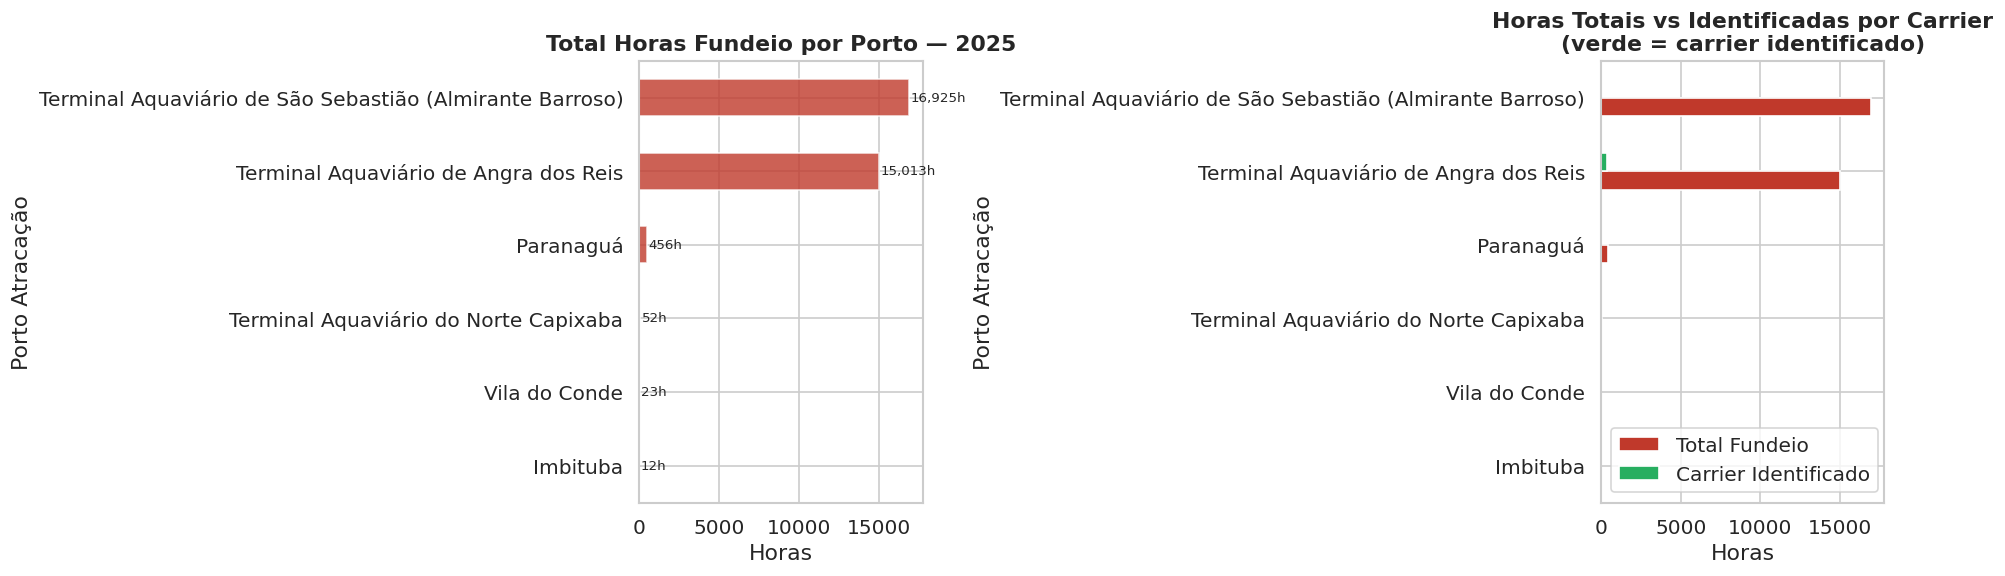


→ Angra dos Reis + São Sebastião representam 98.3% do fundeio total
  Ambos são terminais de petróleo/derivados — não cobertos pelo Vessels_Master (container-only)


In [6]:
# Distribuição por porto — total
porto_fund = (
    fund.groupby('Porto Atracação')['duration_h']
    .agg(Eventos='count', Total_H='sum')
    .sort_values('Total_H', ascending=False)
    .head(10)
)
porto_fund['Share_%'] = (porto_fund['Total_H'] / total_h * 100).round(1)
porto_fund['H_Identificadas'] = fund[fund['carrier_identificado']].groupby('Porto Atracação')['duration_h'].sum().reindex(porto_fund.index).fillna(0).round(1)
porto_fund['% Cobertura'] = (porto_fund['H_Identificadas'] / porto_fund['Total_H'] * 100).round(1)

print('Fundeio por Porto — Top 10:')
print(porto_fund.round(1).to_string())

# Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Horas por porto
colors = ['#c0392b' if '%' in str(s) and float(str(porto_fund['% Cobertura'][i]).replace('%','')) < 5 else '#2980b9'
          for i, s in enumerate(porto_fund.index)]
porto_fund['Total_H'].sort_values().plot.barh(ax=axes[0], color='#c0392b', alpha=0.8)
axes[0].set_title('Total Horas Fundeio por Porto — 2025', fontweight='bold')
axes[0].set_xlabel('Horas')
for i, v_val in enumerate(porto_fund['Total_H'].sort_values().values):
    axes[0].text(v_val + 100, i, f'{v_val:,.0f}h', va='center', fontsize=8)

# Cobertura carrier por porto
porto_cob = porto_fund[['Total_H','H_Identificadas']].sort_values('Total_H', ascending=True)
porto_cob.plot.barh(ax=axes[1], color=['#c0392b', '#27ae60'])
axes[1].set_title('Horas Totais vs Identificadas por Carrier\n(verde = carrier identificado)', fontweight='bold')
axes[1].set_xlabel('Horas')
axes[1].legend(['Total Fundeio','Carrier Identificado'])

plt.tight_layout()
plt.savefig(OUT / 'nb09_01_fundeio_porto.png', bbox_inches='tight')
plt.show()

print(f'\n→ Angra dos Reis + São Sebastião representam {porto_fund.head(2)["Share_%"].sum():.1f}% do fundeio total')
print('  Ambos são terminais de petróleo/derivados — não cobertos pelo Vessels_Master (container-only)')

## 3. Análise Parte 1 — Fundeio por Carrier (container shipping)

### 3.1 Ranking — Horas de Fundeio por Escala

In [7]:
fund_id = fund[fund['carrier_identificado']].copy()

carrier_fundeio = (
    fund_id.groupby('SHIPPING LINE')
    .agg(
        Eventos_Fundeio   = ('duration_h', 'count'),
        Total_H_Fundeio   = ('duration_h', 'sum'),
        Mediana_H_Evento  = ('duration_h', 'median'),
        Max_H_Evento      = ('duration_h', 'max'),
    )
    .reset_index()
)

ranking = carrier_escalas.reset_index().merge(carrier_fundeio, on='SHIPPING LINE', how='left')
ranking['Total_H_Fundeio']   = ranking['Total_H_Fundeio'].fillna(0)
ranking['Eventos_Fundeio']   = ranking['Eventos_Fundeio'].fillna(0).astype(int)
ranking['H_Fundeio_por_Escala'] = (ranking['Total_H_Fundeio'] / ranking['Total_Escalas']).round(3)
ranking['Pct_Escalas_c_Fund'] = (ranking['Eventos_Fundeio'] / ranking['Total_Escalas'] * 100).round(1)
ranking['Share_H_%']         = (ranking['Total_H_Fundeio'] / ranking['Total_H_Fundeio'].sum() * 100).round(1)
ranking = ranking.sort_values('H_Fundeio_por_Escala', ascending=False).reset_index(drop=True)

# Filtro >= 10 escalas
ranking_10 = ranking[ranking['Total_Escalas'] >= 10].copy()

print('RANKING — Horas Fundeio por Escala (carriers com >= 10 escalas identificadas):')
print(ranking_10[['SHIPPING LINE','Total_Escalas','Eventos_Fundeio','Total_H_Fundeio',
                   'Mediana_H_Evento','H_Fundeio_por_Escala','Pct_Escalas_c_Fund','Share_H_%']].to_string(index=False))

print('\nMédia de mercado (carriers identificados):', round(ranking_10['H_Fundeio_por_Escala'].mean(), 3), 'h/escala')

RANKING — Horas Fundeio por Escala (carriers com >= 10 escalas identificadas):
SHIPPING LINE  Total_Escalas  Eventos_Fundeio  Total_H_Fundeio  Mediana_H_Evento  H_Fundeio_por_Escala  Pct_Escalas_c_Fund  Share_H_%
    EVERGREEN            100               14       142.216667          0.616667                 1.422                14.0       30.5
          MSC            169               17       103.850000          0.416667                 0.614                10.1       22.3
       MAERSK            311               27       176.466667          0.466667                 0.567                 8.7       37.8
        COSCO            156               18        38.766667          0.241667                 0.249                11.5        8.3
      CMA CGM             84                6         3.133333          0.550000                 0.037                 7.1        0.7
  Hapag-Lloyd            121                5         1.950000          0.333333                 0.016               

### 3.2 Bar Chart: Total Horas Fundeio + Linha de Média do Mercado

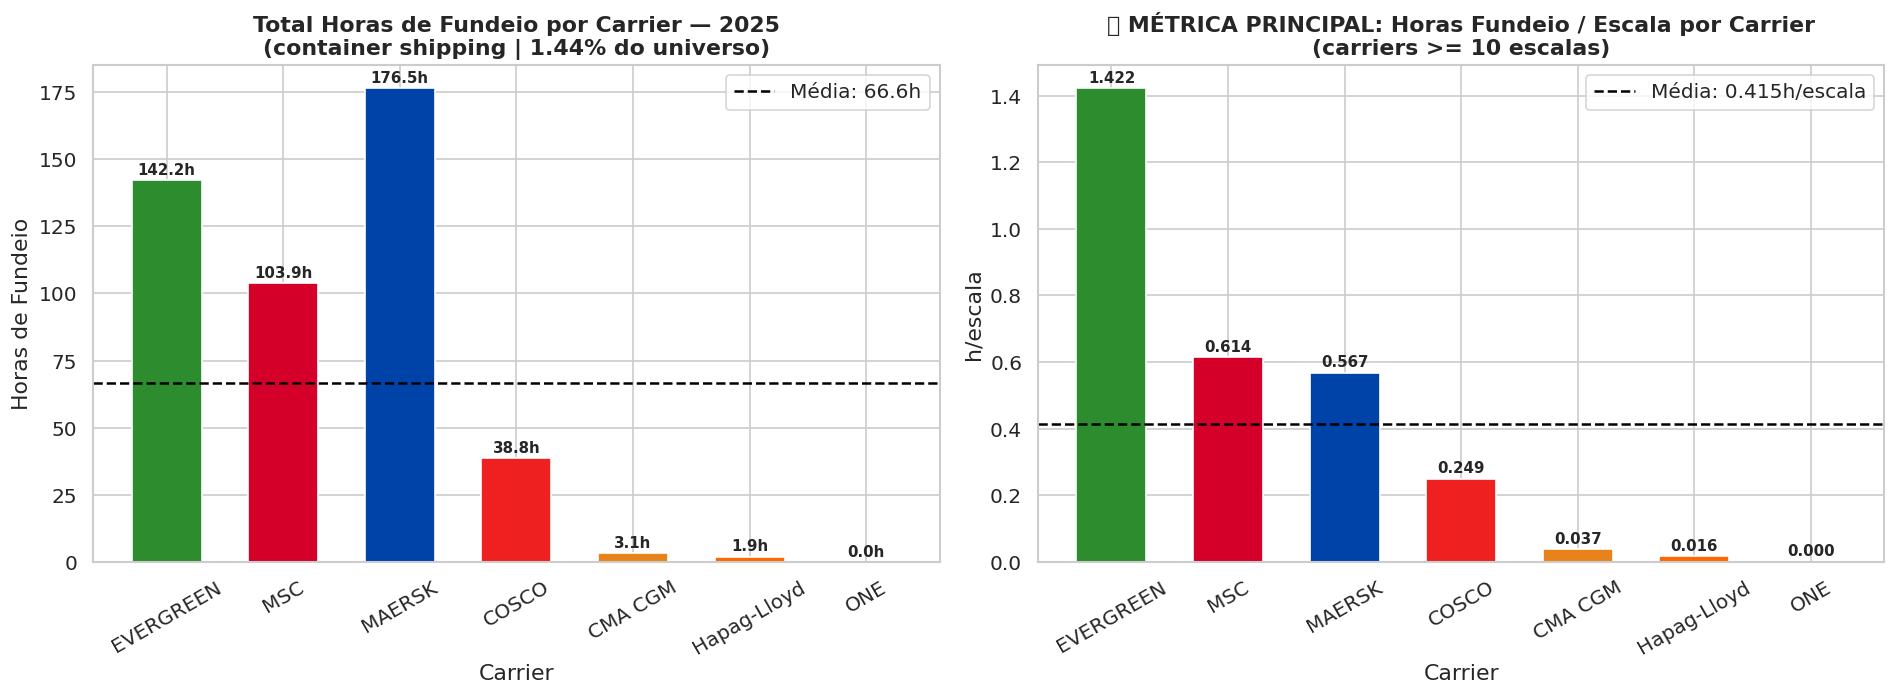

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

r = ranking_10.set_index('SHIPPING LINE')
bar_colors = [CARRIER_COLORS.get(c, '#888888') for c in r.index]

# Gráfico 1: Total horas fundeio com linha de média
bars = axes[0].bar(r.index, r['Total_H_Fundeio'], color=bar_colors, edgecolor='white', width=0.6)
media = r['H_Fundeio_por_Escala'].mean()  # média da ratio, não do total
# linha de média do total proporcional às escalas
total_h_media = r['Total_H_Fundeio'].mean()
axes[0].axhline(total_h_media, color='black', linestyle='--', linewidth=1.5,
                label=f'Média: {total_h_media:.1f}h')
axes[0].set_title('Total Horas de Fundeio por Carrier — 2025\n(container shipping | 1.44% do universo)', 
                  fontweight='bold')
axes[0].set_xlabel('Carrier')
axes[0].set_ylabel('Horas de Fundeio')
axes[0].legend()
for bar, v_val in zip(bars, r['Total_H_Fundeio']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v_val + 1,
                 f'{v_val:.1f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Gráfico 2: Horas fundeio / escala (MÉTRICA PRINCIPAL)
r_sorted = r.sort_values('H_Fundeio_por_Escala', ascending=False)
bar_colors2 = [CARRIER_COLORS.get(c, '#888888') for c in r_sorted.index]
bars2 = axes[1].bar(r_sorted.index, r_sorted['H_Fundeio_por_Escala'], 
                    color=bar_colors2, edgecolor='white', width=0.6)
media_ratio = r_sorted['H_Fundeio_por_Escala'].mean()
axes[1].axhline(media_ratio, color='black', linestyle='--', linewidth=1.5,
                label=f'Média: {media_ratio:.3f}h/escala')
axes[1].set_title('⭐ MÉTRICA PRINCIPAL: Horas Fundeio / Escala por Carrier\n(carriers >= 10 escalas)', 
                  fontweight='bold')
axes[1].set_xlabel('Carrier')
axes[1].set_ylabel('h/escala')
axes[1].legend()
for bar, v_val in zip(bars2, r_sorted['H_Fundeio_por_Escala']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v_val + 0.01,
                 f'{v_val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUT / 'nb09_02_fundeio_carrier.png', bbox_inches='tight')
plt.show()

### 3.3 Scatter: Nº Escalas × Horas Fundeio (tamanho = h/escala)

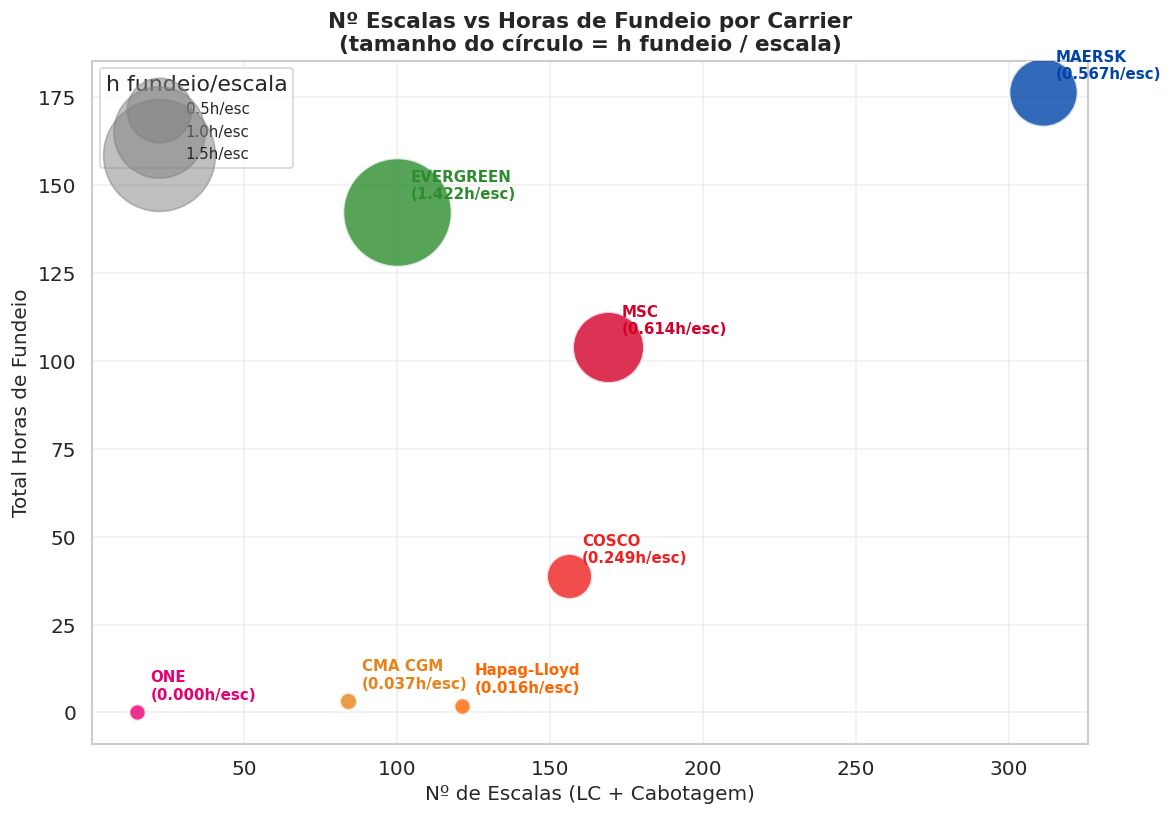

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in ranking_10.iterrows():
    carrier = row['SHIPPING LINE']
    color   = CARRIER_COLORS.get(carrier, '#888888')
    size    = max(row['H_Fundeio_por_Escala'] * 3000, 100)  # mínimo visível
    ax.scatter(row['Total_Escalas'], row['Total_H_Fundeio'],
               s=size, color=color, alpha=0.8, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(f"{carrier}\n({row['H_Fundeio_por_Escala']:.3f}h/esc)",
                xy=(row['Total_Escalas'], row['Total_H_Fundeio']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color)

ax.set_xlabel('Nº de Escalas (LC + Cabotagem)', fontsize=12)
ax.set_ylabel('Total Horas de Fundeio', fontsize=12)
ax.set_title('Nº Escalas vs Horas de Fundeio por Carrier\n'
             '(tamanho do círculo = h fundeio / escala)', fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3)

# Legenda de tamanho
for size_ref, label in [(0.5*3000, '0.5h/esc'), (1.0*3000, '1.0h/esc'), (1.5*3000, '1.5h/esc')]:
    ax.scatter([], [], s=size_ref, color='gray', alpha=0.5, label=label)
ax.legend(title='h fundeio/escala', loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'nb09_03_scatter_escalas_fundeio.png', bbox_inches='tight')
plt.show()

### 3.4 Evolução Mensal por Carrier

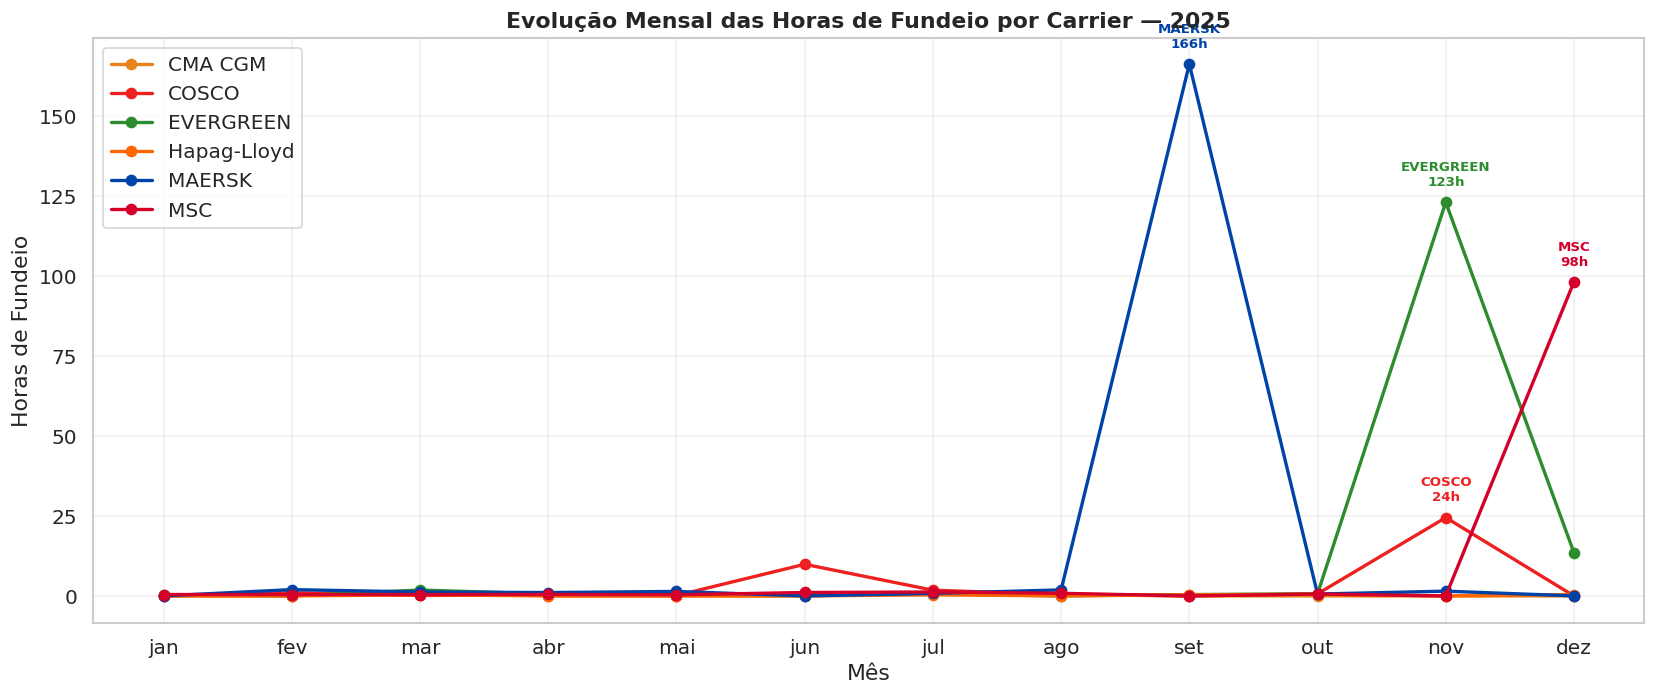

Horas de fundeio por mês e carrier:
SHIPPING LINE  CMA CGM  COSCO  EVERGREEN  Hapag-Lloyd  MAERSK   MSC
Mes                                                                
jan                0.0    0.0        0.4          0.0     0.0   0.4
fev                0.0    1.0        0.0          0.0     2.0   0.4
mar                1.5    0.1        1.8          0.3     1.2   0.4
abr                0.0    0.3        0.6          0.0     1.0   0.4
mai                0.0    0.1        0.4          0.0     1.4   0.4
jun                0.0    9.9        0.8          0.0     0.0   1.1
jul                1.0    1.8        0.6          0.3     0.8   1.2
ago                0.6    0.4        0.0          0.0     1.9   0.8
set                0.0    0.0        0.4          0.3   166.1   0.0
out                0.0    0.6        0.7          0.5     0.6   0.6
nov                0.0   24.5      123.0          0.0     1.5   0.0
dez                0.0    0.0       13.5          0.4     0.0  98.1


In [10]:
mensal = (
    fund_id.groupby(['Mes', 'SHIPPING LINE'])['duration_h']
    .sum()
    .unstack(fill_value=0)
    .reindex(MES_ORDER)
)

fig, ax = plt.subplots(figsize=(14, 6))
for carrier in mensal.columns:
    color = CARRIER_COLORS.get(carrier, '#888888')
    ax.plot(mensal.index, mensal[carrier], marker='o', color=color, 
            linewidth=2, markersize=6, label=carrier)

ax.set_title('Evolução Mensal das Horas de Fundeio por Carrier — 2025', fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Horas de Fundeio')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Anotar picos
for carrier in mensal.columns:
    peak_idx = mensal[carrier].idxmax()
    peak_val = mensal[carrier].max()
    if peak_val > 10:
        ax.annotate(f'{carrier}\n{peak_val:.0f}h',
                    xy=(peak_idx, peak_val),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8,
                    color=CARRIER_COLORS.get(carrier, '#888888'),
                    fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'nb09_04_mensal_carrier.png', bbox_inches='tight')
plt.show()

print('Horas de fundeio por mês e carrier:')
print(mensal.round(1).to_string())

## 4. Análise Parte 2 — Fundeio por Porto

In [11]:
# Top 3 carriers por porto (só carriers identificados)
portos_analise = fund['Porto Atracação'].value_counts().head(8).index.tolist()

porto_carrier = (
    fund_id.groupby(['Porto Atracação', 'SHIPPING LINE'])['duration_h']
    .sum()
    .reset_index()
    .sort_values(['Porto Atracação', 'duration_h'], ascending=[True, False])
)

print('Top carriers por porto (horas fundeio identificadas):')
for porto in porto_carrier['Porto Atracação'].unique():
    subset = porto_carrier[porto_carrier['Porto Atracação'] == porto].head(3)
    total_porto = fund[fund['Porto Atracação'] == porto]['duration_h'].sum()
    id_porto    = fund_id[fund_id['Porto Atracação'] == porto]['duration_h'].sum()
    cob = id_porto / total_porto * 100 if total_porto > 0 else 0
    print(f'\n  {porto} (total: {total_porto:.0f}h | cobertura: {cob:.1f}%)')
    for _, row in subset.iterrows():
        print(f'    {row["SHIPPING LINE"]:<15} {row["duration_h"]:>8.1f}h')

Top carriers por porto (horas fundeio identificadas):

  Paranaguá (total: 456h | cobertura: 6.6%)
    MAERSK              12.5h
    MSC                  6.4h
    EVERGREEN            6.1h

  Terminal Aquaviário de Angra dos Reis (total: 15013h | cobertura: 2.7%)
    MAERSK             164.0h
    EVERGREEN          136.1h
    MSC                 97.5h

  Terminal Aquaviário de São Sebastião (Almirante Barroso) (total: 16925h | cobertura: 0.1%)
    COSCO               24.0h

  Vila do Conde (total: 23h | cobertura: 21.9%)
    COSCO                2.6h
    CMA CGM              2.5h


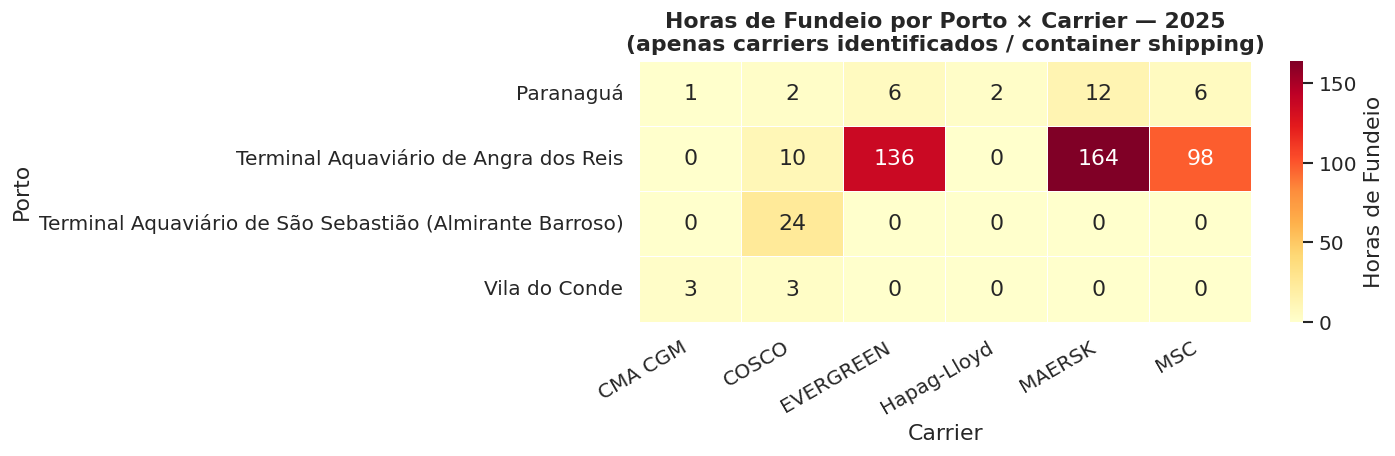

In [12]:
# Heatmap porto × carrier (carriers identificados)
heat_data = (
    fund_id.groupby(['Porto Atracação', 'SHIPPING LINE'])['duration_h']
    .sum()
    .unstack(fill_value=0)
)

# Só portos com fundeio identificado
heat_data = heat_data[heat_data.sum(axis=1) > 0]

if len(heat_data) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(heat_data) * 0.8)))
    sns.heatmap(heat_data, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Horas de Fundeio'})
    ax.set_title('Horas de Fundeio por Porto × Carrier — 2025\n(apenas carriers identificados / container shipping)', 
                 fontweight='bold')
    ax.set_xlabel('Carrier')
    ax.set_ylabel('Porto')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(OUT / 'nb09_05_heatmap_porto_carrier.png', bbox_inches='tight')
    plt.show()
else:
    print('Sem dados suficientes para heatmap')

## 5. Análise Parte 3 — Fundeio por Vessel Segment

In [13]:
SEG_ORDER = [
    'Feeder Max (1k-3k TEU)',
    'Sub-Panamax (3k-8k TEU)',
    'Post-Panamax (8k-12k TEU)',
    'New Panamax (12k-18k TEU)',
    'Ultra Large (> 18k TEU)',
]

seg_fund = (
    fund_id.groupby('vessel_segment')['duration_h']
    .agg(Eventos='count', Total_H='sum', Media_H='mean', Mediana_H='median')
    .reindex(SEG_ORDER)
    .dropna(how='all')
    .round(2)
)

# Escalas por segmento (denominador)
seg_escalas = (
    merged[merged['carrier_identificado']]
    .groupby('vessel_segment')['IDAtracacao']
    .nunique()
    .rename('Escalas_Totais')
)

seg_stats = seg_fund.join(seg_escalas)
seg_stats['H_Fundeio_por_Escala'] = (seg_stats['Total_H'] / seg_stats['Escalas_Totais']).round(3)

print('Fundeio por Vessel Segment (container shipping identificado):')
print(seg_stats.to_string())

# ULCV vs restantes
if 'Ultra Large (> 18k TEU)' in seg_stats.index and 'New Panamax (12k-18k TEU)' in seg_stats.index:
    ulcv_ratio = seg_stats.loc['Ultra Large (> 18k TEU)', 'H_Fundeio_por_Escala']
    np_ratio   = seg_stats.loc['New Panamax (12k-18k TEU)', 'H_Fundeio_por_Escala']
    print(f'\nULCV h/escala    : {ulcv_ratio}')
    print(f'New Panamax h/esc: {np_ratio}')

Fundeio por Vessel Segment (container shipping identificado):
                           Eventos  Total_H  Media_H  Mediana_H  Escalas_Totais  H_Fundeio_por_Escala
vessel_segment                                                                                       
Feeder Max (1k-3k TEU)           8   139.08    17.39       0.61              98                 1.419
Sub-Panamax (3k-8k TEU)         44    51.27     1.17       0.44             340                 0.151
Post-Panamax (8k-12k TEU)       24     9.68     0.40       0.41             384                 0.025
New Panamax (12k-18k TEU)       10   265.93    26.59       0.66             123                 2.162
Ultra Large (> 18k TEU)          1     0.42     0.42       0.42              13                 0.032

ULCV h/escala    : 0.032
New Panamax h/esc: 2.162


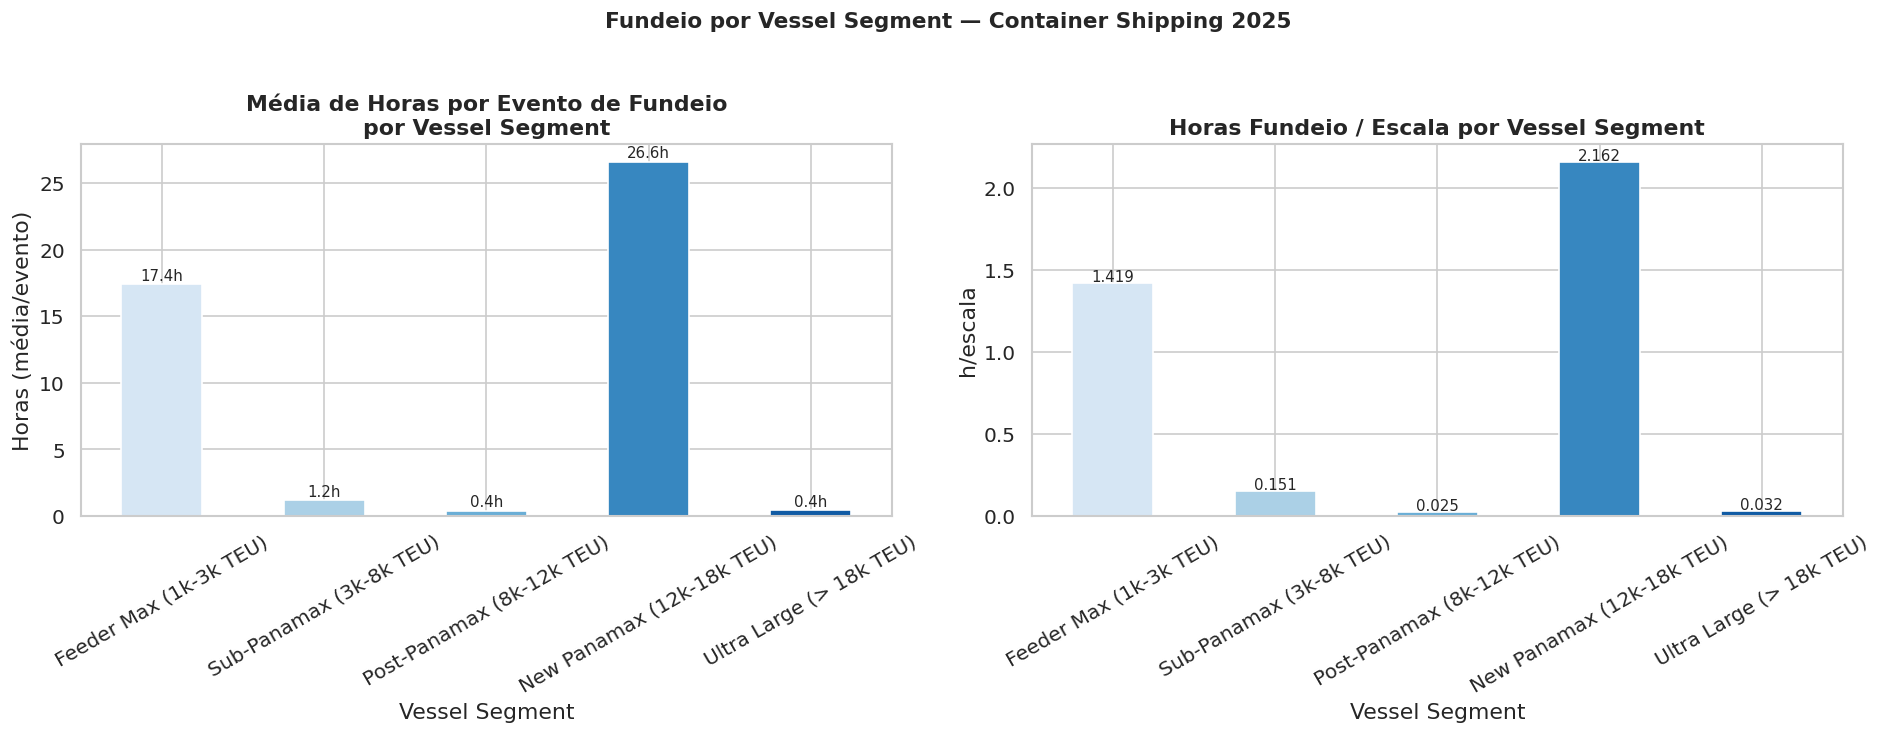


Correlação Pearson TEU × duration_h: 0.200
(positivo = navios maiores tendem a ter mais horas fundeio por evento)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_colors = sns.color_palette('Blues', len(seg_stats))

# Média de horas/evento por segmento
if 'Media_H' in seg_stats.columns:
    seg_stats['Media_H'].plot.bar(ax=axes[0], color=seg_colors, edgecolor='white')
    axes[0].set_title('Média de Horas por Evento de Fundeio\npor Vessel Segment', fontweight='bold')
    axes[0].set_xlabel('Vessel Segment')
    axes[0].set_ylabel('Horas (média/evento)')
    axes[0].tick_params(axis='x', rotation=30)
    for i, v_val in enumerate(seg_stats['Media_H'].fillna(0)):
        axes[0].text(i, v_val + 0.3, f'{v_val:.1f}h', ha='center', fontsize=9)

# H fundeio / escala por segmento
seg_stats['H_Fundeio_por_Escala'].fillna(0).plot.bar(ax=axes[1], color=seg_colors, edgecolor='white')
axes[1].set_title('Horas Fundeio / Escala por Vessel Segment', fontweight='bold')
axes[1].set_xlabel('Vessel Segment')
axes[1].set_ylabel('h/escala')
axes[1].tick_params(axis='x', rotation=30)
for i, v_val in enumerate(seg_stats['H_Fundeio_por_Escala'].fillna(0)):
    axes[1].text(i, v_val + 0.01, f'{v_val:.3f}', ha='center', fontsize=9)

plt.suptitle('Fundeio por Vessel Segment — Container Shipping 2025', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'nb09_06_fundeio_segmento.png', bbox_inches='tight')
plt.show()

# Correlação TEU × horas fundeio (escala por navio)
teu_fund = fund_id[['CAPACIDADE (TEU)', 'duration_h']].dropna()
if len(teu_fund) > 5:
    corr = teu_fund['CAPACIDADE (TEU)'].corr(teu_fund['duration_h'])
    print(f'\nCorrelação Pearson TEU × duration_h: {corr:.3f}')
    print('(positivo = navios maiores tendem a ter mais horas fundeio por evento)')

## 6. Tabela Consolidada por Porto + Carrier Breakdown

In [15]:
# Tabela: fundeio por porto com decomposição carrier vs não-identificado
tabela_porto = (
    fund.groupby('Porto Atracação')
    .agg(
        Total_Eventos = ('duration_h', 'count'),
        Total_H       = ('duration_h', 'sum'),
        H_Identificado = ('carrier_identificado', lambda x: fund.loc[x.index[x == True], 'duration_h'].sum()),
    )
    .sort_values('Total_H', ascending=False)
)
tabela_porto['H_Nao_Id']     = tabela_porto['Total_H'] - tabela_porto['H_Identificado']
tabela_porto['Cobertura_%']  = (tabela_porto['H_Identificado'] / tabela_porto['Total_H'] * 100).round(1)
tabela_porto['Share_Total_%'] = (tabela_porto['Total_H'] / total_h * 100).round(1)

print('Tabela consolidada de Fundeio por Porto — 2025:')
print(tabela_porto.round(1).to_string())

Tabela consolidada de Fundeio por Porto — 2025:
                                                          Total_Eventos  Total_H  H_Identificado  H_Nao_Id  Cobertura_%  Share_Total_%
Porto Atracação                                                                                                                       
Terminal Aquaviário de São Sebastião (Almirante Barroso)            302  16924.6            24.0   16900.6          0.1           52.1
Terminal Aquaviário de Angra dos Reis                               271  15013.1           407.4   14605.7          2.7           46.2
Paranaguá                                                           957    456.2            29.9     426.3          6.6            1.4
Terminal Aquaviário do Norte Capixaba                                 2     51.9             0.0      51.9          0.0            0.2
Vila do Conde                                                       102     23.2             5.1      18.1         21.9            0.1
Imbitub

## 7. Export e Nota de Cobertura

In [16]:
# Exportar ranking
ranking_10.to_csv(PROC / 'fundeio_ranking_carrier_2025.csv', index=False)
tabela_porto.to_csv(PROC / 'fundeio_por_porto_2025.csv')

print('Exportado: fundeio_ranking_carrier_2025.csv')
print('Exportado: fundeio_por_porto_2025.csv')

Exportado: fundeio_ranking_carrier_2025.csv
Exportado: fundeio_por_porto_2025.csv


## 8. Limitações Metodológicas

In [17]:
h_noid_pct = (total_h - h_id) / total_h * 100

print('=' * 70)
print('NOTA DE COBERTURA E LIMITAÇÕES METODOLÓGICAS')
print('=' * 70)
print()
print(f'1. COBERTURA DE CARRIER')
print(f'   {h_noid_pct:.1f}% das horas de fundeio (LC + Cabotagem) são de navios')
print(f'   não cobertos pelo Vessels_Master_Enriched.')
print(f'   O fundeio é dominado por terminais de petróleo (Angra dos Reis e')
print(f'   São Sebastião) onde operam tankers/VLCC — não container lines.')
print(f'   O Vessels_Master só cobre container shipping. Consequência:')
print(f'   carriers não identificados podem ter performance melhor ou pior')
print(f'   que a média — viés de selecção não quantificável.')
print()
print(f'2. CAUSALIDADE DO FUNDEIO')
print(f'   As horas de fundeio reflectem combinação de:')
print(f'   (a) Scheduling do carrier — chegada antes do berço estar disponível')
print(f'   (b) Disponibilidade de berço — congestionamento portuário')
print(f'   (c) Condições operacionais do porto — maré, calado, equipamentos')
print(f'   Não é possível separar a contribuição de cada factor com os dados')
print(f'   disponíveis. Não atribuir causalidade exclusiva ao carrier.')
print()
print(f'3. ÂMBITO TEMPORAL')
print(f'   Análise cobre apenas 2025. Sem comparação inter-anual.')
print(f'   Picos mensais (ex: Maersk Set/2025 em Paranaguá: 166h;')
print(f'   Evergreen Nov/2025 em Angra: 123h) podem ser eventos pontuais,')
print(f'   não padrão estrutural.')
print()
print(f'4. ESCOPO DO RANKING')
print(f'   Ranking cobre 6 carriers com >= 10 escalas identificadas.')
print(f'   ONE (15 escalas, 0 fundeio) e ZIM (2 escalas) incluídos na análise')
print(f'   mas podem reflectir escassa cobertura no dataset, não performance real.')
print('=' * 70)

NOTA DE COBERTURA E LIMITAÇÕES METODOLÓGICAS

1. COBERTURA DE CARRIER
   98.6% das horas de fundeio (LC + Cabotagem) são de navios
   não cobertos pelo Vessels_Master_Enriched.
   O fundeio é dominado por terminais de petróleo (Angra dos Reis e
   São Sebastião) onde operam tankers/VLCC — não container lines.
   O Vessels_Master só cobre container shipping. Consequência:
   carriers não identificados podem ter performance melhor ou pior
   que a média — viés de selecção não quantificável.

2. CAUSALIDADE DO FUNDEIO
   As horas de fundeio reflectem combinação de:
   (a) Scheduling do carrier — chegada antes do berço estar disponível
   (b) Disponibilidade de berço — congestionamento portuário
   (c) Condições operacionais do porto — maré, calado, equipamentos
   Não é possível separar a contribuição de cada factor com os dados
   disponíveis. Não atribuir causalidade exclusiva ao carrier.

3. ÂMBITO TEMPORAL
   Análise cobre apenas 2025. Sem comparação inter-anual.
   Picos mensais (ex: